In [1]:
from pathlib import Path
import sys
import time
import statistics

import torch
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [7]:
cwd = Path.cwd()

if cwd.name == "notebooks":
    project_root = cwd.parent
else:
    project_root = cwd

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)

Project root: /Users/salmannasyrov/PycharmProjects/ai360-recsys-2026


In [8]:
from src.polynomial import (
    PolynomialRegression2,
    FactorizedPolynomialRegression,
)

In [9]:
torch.manual_seed(42)

model = FactorizedPolynomialRegression(
    n_features=20,
    n_factors=16,
).double()

x = torch.randn(
    32,
    20,
    dtype=torch.float64,
)

with torch.no_grad():
    direct = model.interaction_direct(x)
    fast = model.interaction_fast(x)

max_difference = (direct - fast).abs().max().item()

print("Maximum absolute difference:", max_difference)
print("Direct and fast are equal:",
      torch.allclose(direct, fast, rtol=1e-10, atol=1e-10))

Maximum absolute difference: 7.589415207398531e-18
Direct and fast are equal: True


In [11]:
def count_trainable_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

In [12]:
n_factors = 16

feature_sizes = [
    10,
    50,
    100,
    200,
    500,
    1000,
]

parameter_results = []

for n_features in feature_sizes:
    polynomial = PolynomialRegression2(
        n_features=n_features,
    )

    factorized = FactorizedPolynomialRegression(
        n_features=n_features,
        n_factors=n_factors,
    )

    polynomial_params = count_trainable_parameters(
        polynomial
    )

    factorized_params = count_trainable_parameters(
        factorized
    )

    parameter_results.append({
        "n_features": n_features,
        "polynomial_params": polynomial_params,
        "factorized_params": factorized_params,
        "polynomial / factorized": (
            polynomial_params / factorized_params
        ),
    })

parameter_df = pd.DataFrame(parameter_results)

parameter_df

,n_features,polynomial_params,factorized_params,polynomial / factorized
0,10,56,171,0.327485
1,50,1276,851,1.499412
2,100,5051,1701,2.969430
3,200,20101,3401,5.910320
4,500,125251,8501,14.733678
5,1000,500501,17001,29.439504


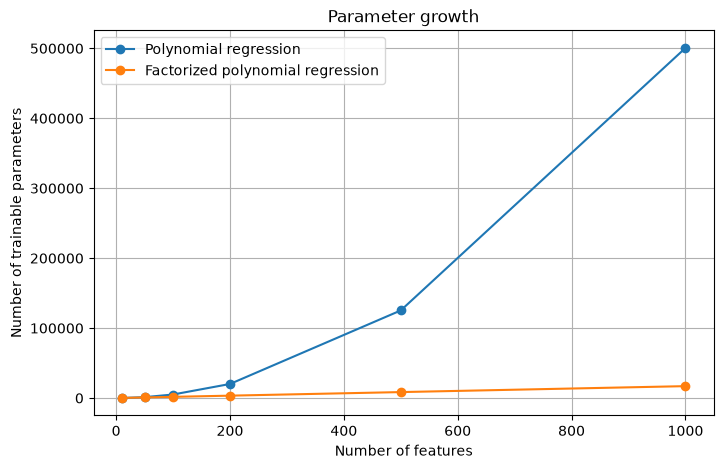

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    parameter_df["n_features"],
    parameter_df["polynomial_params"],
    marker="o",
    label="Polynomial regression",
)

plt.plot(
    parameter_df["n_features"],
    parameter_df["factorized_params"],
    marker="o",
    label="Factorized polynomial regression",
)

plt.xlabel("Number of features")
plt.ylabel("Number of trainable parameters")
plt.title("Parameter growth")
plt.legend()
plt.grid()

plt.show()

In [14]:
def measure_time(
    function,
    x,
    repeats=30,
    warmup=5,
):
    with torch.no_grad():
        for _ in range(warmup):
            function(x)

        measurements = []

        for _ in range(repeats):
            start = time.perf_counter()

            function(x)

            end = time.perf_counter()

            measurements.append(
                end - start
            )

    return statistics.median(measurements)

In [15]:
torch.manual_seed(42)

n_factors = 16
batch_size = 32

feature_sizes = [
    10,
    50,
    100,
    200,
    500,
    1000,
]

benchmark_results = []

for n_features in feature_sizes:
    model = FactorizedPolynomialRegression(
        n_features=n_features,
        n_factors=n_factors,
    )

    x = torch.randn(
        batch_size,
        n_features,
    )

    direct_time = measure_time(
        model.interaction_direct,
        x,
    )

    fast_time = measure_time(
        model.interaction_fast,
        x,
    )

    with torch.no_grad():
        direct = model.interaction_direct(x)
        fast = model.interaction_fast(x)

    max_difference = (
        direct - fast
    ).abs().max().item()

    benchmark_results.append({
        "n_features": n_features,
        "direct_ms": direct_time * 1000,
        "fast_ms": fast_time * 1000,
        "speedup": direct_time / fast_time,
        "max_difference": max_difference,
    })

benchmark_df = pd.DataFrame(
    benchmark_results
)

benchmark_df

,n_features,direct_ms,fast_ms,speedup,max_difference
0,10,0.024229,0.013958,1.735850,1.396984e-09
1,50,0.303854,0.011896,25.543608,1.024455e-08
2,100,0.233042,0.010521,22.150128,2.235174e-08
3,200,0.730375,0.010167,71.841341,1.043081e-07
4,500,5.190980,0.025604,202.740964,2.533197e-07
5,1000,23.265104,0.017396,1337.420822,7.525086e-07


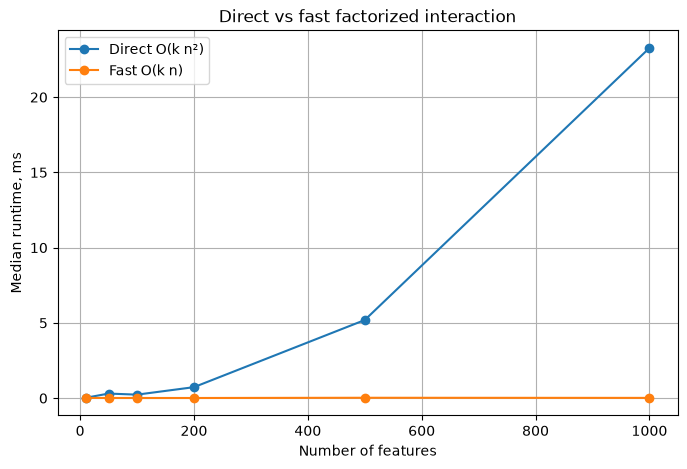

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    benchmark_df["n_features"],
    benchmark_df["direct_ms"],
    marker="o",
    label="Direct O(k n²)",
)

plt.plot(
    benchmark_df["n_features"],
    benchmark_df["fast_ms"],
    marker="o",
    label="Fast O(k n)",
)

plt.xlabel("Number of features")
plt.ylabel("Median runtime, ms")
plt.title("Direct vs fast factorized interaction")
plt.legend()
plt.grid()

plt.show()

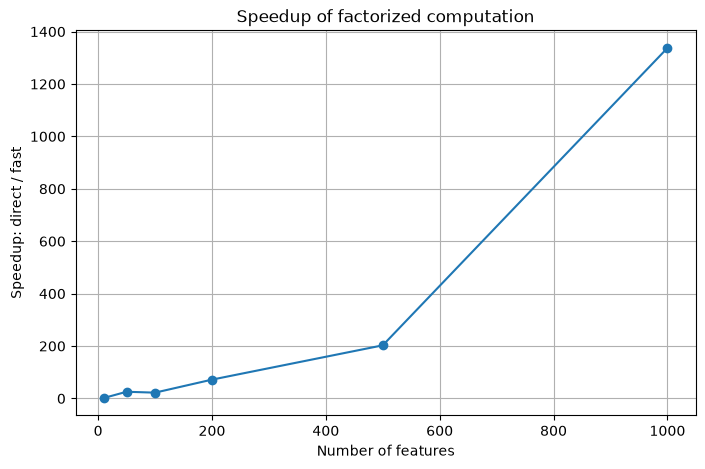

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    benchmark_df["n_features"],
    benchmark_df["speedup"],
    marker="o",
)

plt.xlabel("Number of features")
plt.ylabel("Speedup: direct / fast")
plt.title("Speedup of factorized computation")
plt.grid()

plt.show()

In [19]:
theory_results = []

for n_features in feature_sizes:
    n_pairs = (
        n_features
        * (n_features - 1)
        // 2
    )

    polynomial_interaction_params = n_pairs

    factorized_interaction_params = (
        n_features * n_factors
    )

    theory_results.append({
        "n_features": n_features,
        "number_of_pairs": n_pairs,
        "polynomial_interaction_params":
            polynomial_interaction_params,
        "factorized_interaction_params":
            factorized_interaction_params,
        "compression_ratio":
            polynomial_interaction_params
            / factorized_interaction_params,
    })

theory_df = pd.DataFrame(
    theory_results
)

theory_df

,n_features,number_of_pairs,polynomial_interaction_params,factorized_interaction_params,compression_ratio
0,10,45,45,160,0.28125
1,50,1225,1225,800,1.53125
2,100,4950,4950,1600,3.09375
3,200,19900,19900,3200,6.21875
4,500,124750,124750,8000,15.59375
5,1000,499500,499500,16000,31.21875
